In [66]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings 
warnings.filterwarnings('ignore')


df = pd.read_csv('../DataSet/loan_approval_dataset.csv')

df.columns = df.columns.str.strip()
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [67]:
print("NUll Values : " , df.isnull().sum())
print("Dublicate Values :" , df.duplicated().sum())
print("Columns  :" , df.columns)
print("Shape  :" , df.shape)

NUll Values :  loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
Dublicate Values : 0
Columns  : Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
Shape  : (4269, 13)


In [68]:
# df_clean 
col = ['education', 'self_employed','income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'loan_status']
df_clean =df[col].copy()

# assets combine kar diye
df_clean['assets_value'] = (
    df['residential_assets_value'] + 
    df['commercial_assets_value'] + 
    df['luxury_assets_value'] + 
    df['bank_asset_value']
)

df_clean['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [69]:
# DATA PREPROCESSING (CLeaning)

df_clean['education'] = df_clean['education'].str.strip().map({"Graduate": 1, "Not Graduate":0 })
df_clean['loan_status'] =df_clean['loan_status'].str.strip().map({'Approved': 1, 'Rejected': 0})
df_clean['self_employed'] = df_clean['self_employed'].str.strip()
df_clean['self_employed'] = df_clean['self_employed'].map({"Yes": 1, "No":0 })
df_clean.head()

,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,assets_value
0,1,0,9600000,29900000,12,778,1,50700000
1,0,1,4100000,12200000,8,417,0,17000000
2,1,0,9100000,29700000,20,506,0,57700000
3,1,0,8200000,30700000,8,467,0,52700000
4,0,1,9800000,24200000,20,382,0,55000000


education , self_employed , income_annum , loan_amount , loan_term , cibil_score , loan_status , assets_value , 

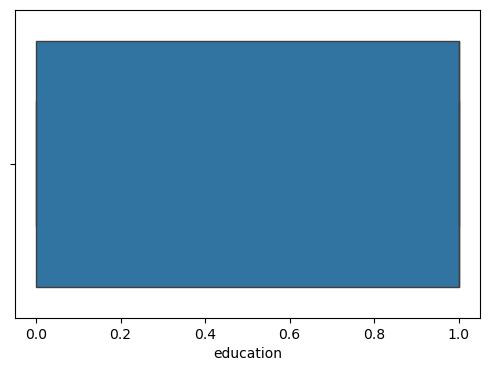

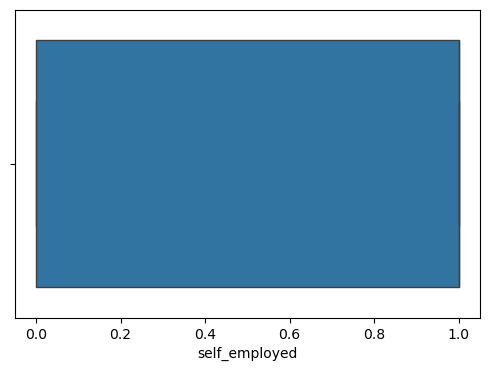

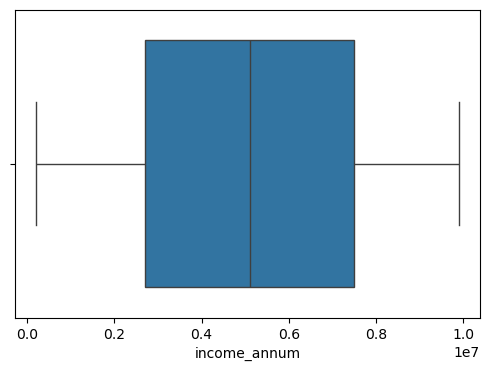

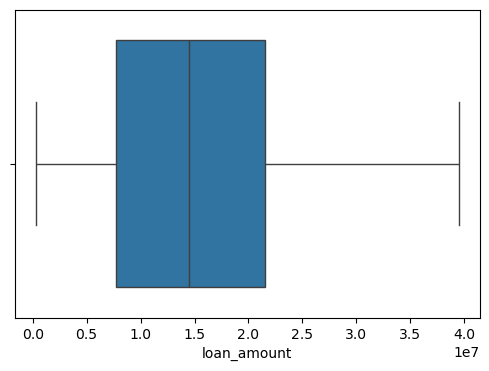

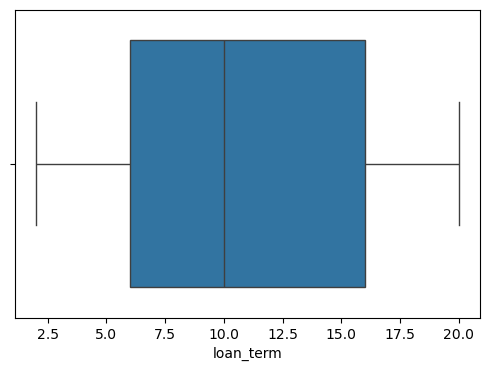

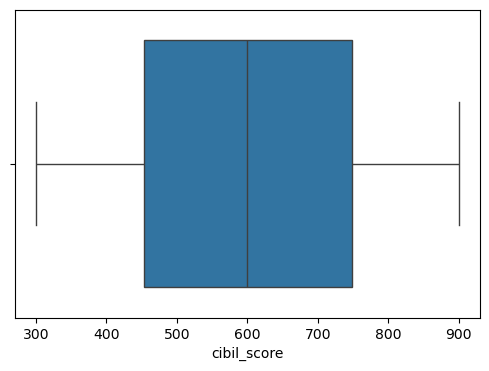

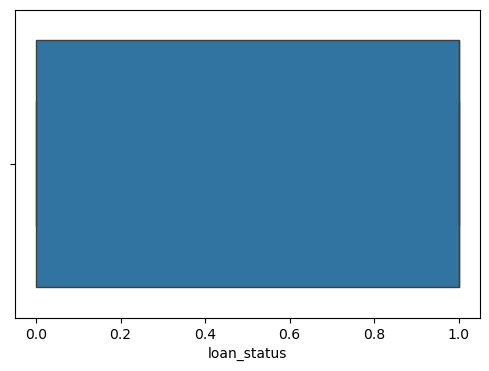

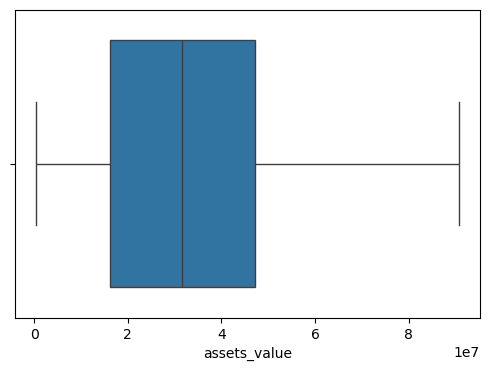

In [70]:
# Outliers
col =['education', 'self_employed','income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'loan_status' , 'assets_value']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

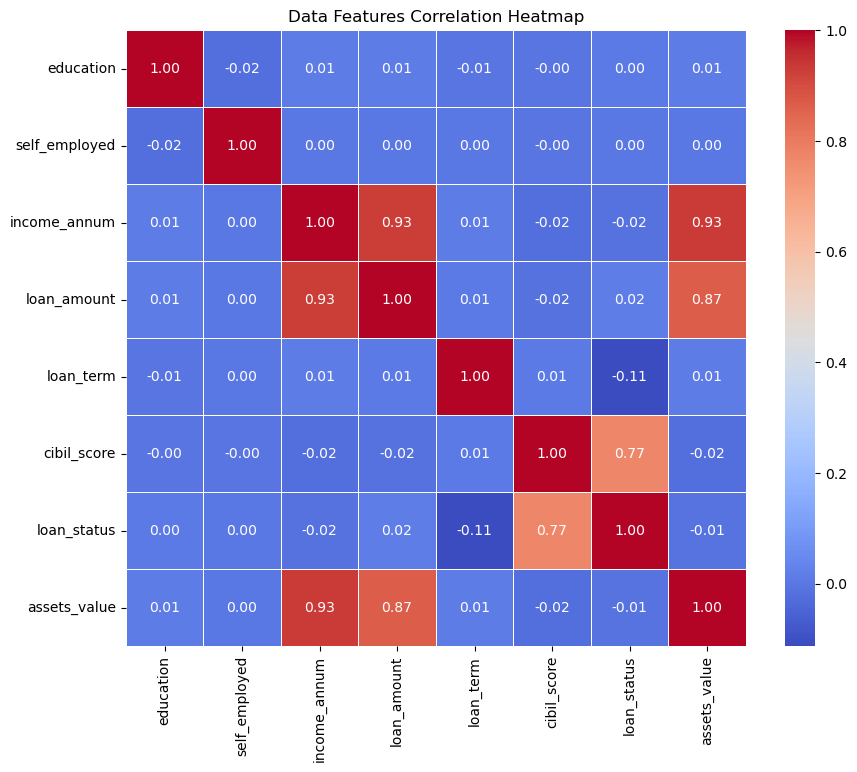

In [75]:
plt.figure(figsize=(10, 8))
# Heatmap plot karein
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Data Features Correlation Heatmap')
plt.show()

In [74]:
col=['education', 'self_employed','income_annum', 'loan_amount', 'loan_term', 'cibil_score' ,'assets_value']

X = df_clean[col]
y = df_clean['loan_status']

model = LogisticRegression(max_iter=1000)

model.fit(X,y)
print(df_clean.head())


edu = float(input("Enter education (Graduation: 1, Not Graduate: 0): "))
self_emp = float(input("Enter self employed (Yes: 1, No: 0): "))
income = float(input("Enter Annual Income: "))
loan_amt = float(input("Enter Loan Amount: "))
loan_term = float(input("Enter Loan Term (in years/months): "))
cibil = float(input("Enter CIBIL Score: "))
assets = float(input("Enter Total Assets Value: "))
result = model.predict([[edu, self_emp, income, loan_amt, loan_term, cibil, assets]])[0]

print("Prediciton :"  , result)

prob = model.predict_proba([[edu, self_emp, income, loan_amt, loan_term, cibil, assets]])

print(f"Rejected Probability: {round(prob[0][0] * 100, 2)}%")
print(f"Approved Probability: {round(prob[0][1] * 100, 2)}%")

# 6. Model Accuracy
y_pred = model.predict(X)
print(f"\nModel Accuracy: {round(accuracy_score(y, y_pred) * 100, 2)}%")

# visuals
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Model Confusion Matrix')
plt.show()

   education  self_employed  ...  loan_status  assets_value
0          1              0  ...            1      50700000
1          0              1  ...            0      17000000
2          1              0  ...            0      57700000
3          1              0  ...            0      52700000
4          0              1  ...            0      55000000

[5 rows x 8 columns]


Enter education (Graduation: 1, Not Graduate: 0):  1
Enter self employed (Yes: 1, No: 0):  1
Enter Annual Income:  0
Enter Loan Amount:  450000
Enter Loan Term (in years/months):  12
Enter CIBIL Score:  800
Enter Total Assets Value:  450000


Prediciton : 1
Rejected Probability: 2.28%
Approved Probability: 97.72%

Model Accuracy: 78.89%


In [77]:
df_clean.head()

,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,assets_value
0,1,0,9600000,29900000,12,778,1,50700000
1,0,1,4100000,12200000,8,417,0,17000000
2,1,0,9100000,29700000,20,506,0,57700000
3,1,0,8200000,30700000,8,467,0,52700000
4,0,1,9800000,24200000,20,382,0,55000000


🔥 Nayi Test Accuracy: 98.01% (Pehle se bohot behtar!)

--------------------------------------------------
👉 ENTER VALUES FOR PREDICTION:


Enter Annual Income:  1000000
Enter Loan Amount:  4500000
Enter Loan Term (in years/months):  48
Enter CIBIL Score:  750
Enter Total Assets Value:  1000000


--------------------------------------------------
Prediction Status: ✅ Approved
Rejected Probability: 42.05%
Approved Probability: 57.95%
--------------------------------------------------


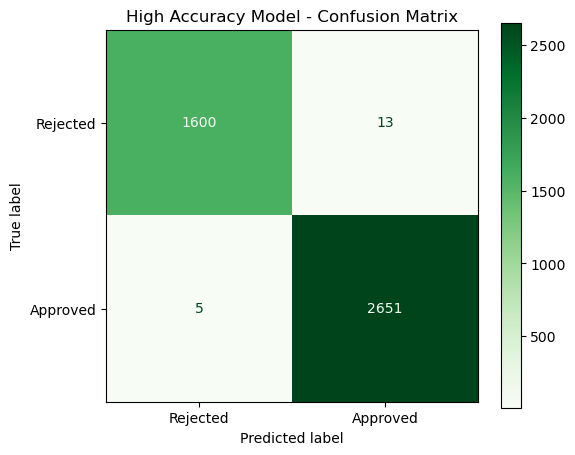

In [76]:
# by me only for increasing the model aaccuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Features (X) aur Target (y) select karein (Bekar columns drop karke)
# Humne heatmap ke mutabik highly correlated aur low-impact columns ko manage kiya hai
X_cols = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'assets_value']
X = df_clean[X_cols]
y = df_clean['loan_status']

# 2. Data ko Train aur Test sets mein split karein (Best practice for ML)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling (Bohot zaroori hai high accuracy ke liye)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sabhi data ko scale karne ke liye (Taaki pooray dataset par accuracy nikaal sakein)
X_scaled = scaler.transform(X)

# 4. Powerful Model Train Karein (Random Forest Classifier)
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)

# 5. Accuracy Check Karein
y_pred_test = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred_test) * 100
print(f"🔥 Nayi Test Accuracy: {round(test_acc, 2)}% (Pehle se bohot behtar!)\n")

# --- USER INPUT SECTION ---
print("-" * 50)
print("👉 ENTER VALUES FOR PREDICTION:")
income = float(input("Enter Annual Income: "))
loan_amt = float(input("Enter Loan Amount: "))
loan_term = float(input("Enter Loan Term (in years/months): "))
cibil = float(input("Enter CIBIL Score: "))
assets = float(input("Enter Total Assets Value: "))


user_features = np.array([[income, loan_amt, loan_term, cibil, assets]])
user_features_scaled = scaler.transform(user_features)

# Predict karein
result = model.predict(user_features_scaled)[0]
prob = model.predict_proba(user_features_scaled)

status = "✅ Approved" if result == 1 else "❌ Rejected"
print("-" * 50)
print("Prediction Status:", status)
print(f"Rejected Probability: {round(prob[0][0] * 100, 2)}%")
print(f"Approved Probability: {round(prob[0][1] * 100, 2)}%")
print("-" * 50)

# --- VISUALS (Confusion Matrix) ---
y_pred_all = model.predict(X_scaled)
cm = confusion_matrix(y, y_pred_all)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('High Accuracy Model - Confusion Matrix')
plt.show()

In [73]:
# save df_clean
df_clean.to_csv('loan_approval_dataset_cleaned.csv', index=False)